# Wafer Anomaly Detection — Fine-Tuned ViT-B/16 Backbone + PatchCore (WM-811K)

**Hardware target:** RTX 4060 Laptop GPU (8 GB VRAM)

## Why Training Matters for Your Course Project

Your existing notebook uses **PatchCore in pure inference mode** — the ViT backbone is frozen
ImageNet weights. No gradient update ever happens on your wafer data. PatchCore itself has
no learnable parameters either; it just builds a nearest-neighbour memory bank.

A course project that requires **training** needs at least one stage where weights are updated
on *your* dataset. This notebook adds that stage:

```
Stage 1 ─ Self-Supervised Pre-Training (normal wafers only)
          SimSiam / Rotation-Prediction on normal data
          → backbone learns wafer-specific representations WITHOUT labels

Stage 2 ─ PatchCore Memory Bank Build
          Use the fine-tuned backbone to extract patch embeddings
          → memory bank captures what "normal" looks like in learned space

Stage 3 ─ Threshold Tuning & Evaluation
          Same as your original notebook
```

## Method Comparison — why this approach?

| Method | Trains on normal only? | Needs defect labels? | Notes |
|---|---|---|---|
| **PatchCore (original)** | ✓ | ✗ | No training at all — ImageNet features |
| **Fine-tune + PatchCore (this)** | ✓ | ✗ | Best of both worlds |
| Knowledge Distillation (e.g. STFPM) | ✓ | ✗ | Teacher frozen, student trained — good alternative |
| Autoencoder / VAE | ✓ | ✗ | Reconstruction error = anomaly score |
| Deep SVDD | ✓ | ✗ | Learns hypersphere around normal |
| Standard CNN classifier | ✗ | ✓ | Needs defect labels — not unsupervised |

**Self-supervised pre-training then PatchCore** is state-of-the-art for industrial anomaly
detection and is exactly what papers like PatchCore + ImageNet do — except here we replace
the frozen ImageNet backbone with a wafer-domain-adapted one.

## Pipeline (VRAM budget: 8 GB)

```
1. Load & split WM-811K  (normal only for train/tune; test has both)
2. Fine-tune ViT-B/16 with rotation prediction (4-class: 0°/90°/180°/270°)
   — only last 4 transformer blocks + classifier head updated
   — ~30 min on RTX 4060 for 5 epochs, 40k normals
3. Build PatchCore memory bank with fine-tuned features
4. Tune threshold on tune-normal (no defect leakage)
5. Evaluate on held-out test split
```

## Why Rotation Prediction?

- **No labels required** — we generate pseudo-labels by rotating images
- **Forces the model to understand structure** — the network must learn what a normal
  wafer looks like at each orientation → better features for anomaly detection
- **Computationally cheap** — 4-class classification is simpler than contrastive learning
- **Proven** — rotation prediction is a classic SSL pretext task that transfers well

In [171]:
# ── 0. Install dependencies ────────────────────────────────────────────────────
import importlib, subprocess, sys
for pkg in ['timm', 'tqdm']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('timm + tqdm ready')

timm + tqdm ready


In [172]:
# ── 1. Imports ─────────────────────────────────────────────────────────────────
import os, gc, random, warnings, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Device:', DEVICE)
if USE_CUDA:
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  VRAM: 8.6 GB


In [173]:
# ── 2. Configuration ───────────────────────────────────────────────────────────
DATA_PATH  = '../../data/raw/LSWMD.pkl'   # ← adjust to your path
IMAGE_SIZE = 224

# ── Data splits ──
TRAIN_NORMAL_N = 40_000   # used for fine-tuning AND memory bank
TUNE_NORMAL_N  =  5_000   # for threshold calibration (normal only)
TEST_NORMAL_N  =  5_000   # final evaluation
TEST_DEFECT_N  =    250   # final evaluation

# ── Fine-tuning settings ──
# We only unfreeze the last N transformer blocks + head to save VRAM.
# ViT-B/16 has 12 blocks. Unfreezing the last 4 is a good balance.
UNFREEZE_BLOCKS  = 4       # unfreeze blocks [8,9,10,11] of 12
FINETUNE_EPOCHS  = 5       # 5 epochs is enough for SSL pretext task
FINETUNE_LR      = 3e-5    # small LR to avoid catastrophic forgetting
FINETUNE_BATCH   = 64      # 64 fits in 8 GB VRAM with ViT-B/16
NUM_ROT_CLASSES  = 4       # 0°, 90°, 180°, 270°
FINETUNE_WORKERS = 0       # set to 4 on Linux for speed; 0 on Windows

# ── PatchCore settings ──
VIT_FEATURE_BLOCK    = 9      # which block to hook for patch features
PATCH_EMBED_DIM      = 128    # project 768-d → 128-d
MEMORY_BANK_MAX      = 600_000
SCORE_CHUNK          = 512    # reduce to 256 if CUDA OOM
PATCHCORE_NN_K       = 3
TOPK_PATCH_RATIO     = 0.1
BANK_BATCH_SIZE      = 128
BANK_WORKERS         = 0

# ── Threshold sweep ──
THRESHOLD_PERCENTILE_MIN   = 90
THRESHOLD_PERCENTILE_MAX   = 99.9
THRESHOLD_GRID_STEPS       = 300

# ── Outputs ──
ARTIFACT_DIR          = '../artifacts/trained_patchcore'
FINETUNE_CKPT         = os.path.join(ARTIFACT_DIR, 'vit_finetuned.pt')
MODEL_EXPORT_PATH     = os.path.join(ARTIFACT_DIR, 'patchcore_trained_model.pt')
METRICS_EXPORT_PATH   = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'Fine-tune: {FINETUNE_EPOCHS} epochs, LR={FINETUNE_LR}, batch={FINETUNE_BATCH}')
print(f'PatchCore: block={VIT_FEATURE_BLOCK}, embed={PATCH_EMBED_DIM}, bank_cap={MEMORY_BANK_MAX:,}')
print(f'Artifacts → {ARTIFACT_DIR}')

Fine-tune: 5 epochs, LR=3e-05, batch=64
PatchCore: block=9, embed=128, bank_cap=600,000
Artifacts → ../artifacts/trained_patchcore


In [174]:
# ── 3. Load & clean dataset ────────────────────────────────────────────────────
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(v):
    if v is None: return 'unknown'
    if isinstance(v, float) and np.isnan(v): return 'unknown'
    if isinstance(v, (list, tuple, np.ndarray)):
        a = np.array(v).reshape(-1)
        return 'unknown' if len(a) == 0 else str(a[0])
    return str(v)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).str.strip()

invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print(f'Labeled: {len(df):,}   Normal: {len(normal_df):,}   Defect: {len(defect_df):,}')
print('\nDefect breakdown:')
print(defect_df['failure_label'].value_counts())

Raw shape: (811457, 6)
Labeled: 172,950   Normal: 147,431   Defect: 25,519

Defect breakdown:
failure_label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [175]:
# ── 4. Split ───────────────────────────────────────────────────────────────────
# test_defect_df keeps 'failure_label' so we can do per-class evaluation later.
req_n = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
req_d = TEST_DEFECT_N

if len(normal_df) < req_n:
    raise ValueError(f'Need {req_n:,} normals, have {len(normal_df):,}')
if len(defect_df) < req_d:
    raise ValueError(f'Need {req_d:,} defects, have {len(defect_df):,}')

rng = np.random.default_rng(SEED)
ns = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
ds = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

a = TRAIN_NORMAL_N
b = a + TUNE_NORMAL_N
c = b + TEST_NORMAL_N

train_normal_df = ns.iloc[0:a].copy()
tune_normal_df  = ns.iloc[a:b].copy()
test_normal_df  = ns.iloc[b:c].copy()
# Keep failure_label column — used for per-class evaluation in cell 13
test_defect_df  = ds.iloc[0:TEST_DEFECT_N].copy()

del normal_df, defect_df, ns, ds
gc.collect()

print(f'Train normal : {len(train_normal_df):>7,}  (fine-tuning + memory bank)')
print(f'Tune  normal : {len(tune_normal_df):>7,}  (threshold calibration — normal only, no leakage)')
print(f'Test  normal : {len(test_normal_df):>7,}')
print(f'Test  defect : {len(test_defect_df):>7,}')
print(f'\nDefect classes in test set:')
print(test_defect_df['failure_label'].value_counts())


Train normal :  40,000  (fine-tuning + memory bank)
Tune  normal :   5,000  (threshold calibration — normal only, no leakage)
Test  normal :   5,000
Test  defect :     250

Defect classes in test set:
failure_label
Edge-Ring    102
Edge-Loc      44
Loc           41
Center        34
Random        13
Scratch       11
Near-full      3
Donut          2
Name: count, dtype: int64


In [176]:
# ── 5. Lazy WaferDataset (same RAM-efficient design as original notebook) ───────
#
# BaseWaferDataset: converts wafer maps on-the-fly, one sample at a time.
# RotationDataset: wraps BaseWaferDataset and adds pseudo rotation labels
#                  for self-supervised fine-tuning.

class BaseWaferDataset(Dataset):
    """Lazy dataset — stores raw numpy maps, converts to tensors per batch."""

    def __init__(self, frame: pd.DataFrame, size: int = 224):
        self.maps   = frame['waferMap'].values
        self.labels = frame['is_anomaly'].values.astype(np.int64)
        self.size   = size

    def _map_to_tensor(self, idx):
        arr = np.clip(np.array(self.maps[idx], dtype=np.int64), 0, 2)
        x   = torch.tensor(arr, dtype=torch.long)
        x   = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()  # [3, H, W]
        x   = F.interpolate(
                  x.unsqueeze(0),
                  size=(self.size, self.size),
                  mode='nearest'
              ).squeeze(0)
        return x

    def __len__(self):
        return len(self.maps)

    def __getitem__(self, idx):
        return self._map_to_tensor(idx), int(self.labels[idx])


class RotationDataset(Dataset):
    """
    Self-supervised rotation prediction dataset.

    For each sample, randomly pick a rotation angle (0/90/180/270) and
    return (rotated_tensor, rotation_class_index).

    This is the TRAINING signal — the backbone must learn which way
    the wafer is oriented, which forces it to understand the global
    structure of normal wafers.
    """

    ANGLES = [0, 1, 2, 3]   # k in torch.rot90: 0°, 90°, 180°, 270°

    def __init__(self, base_dataset: BaseWaferDataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, _ = self.base[idx]                        # ignore anomaly label
        k     = random.randint(0, 3)
        x_rot = torch.rot90(x, k=k, dims=[1, 2])    # rotate in H×W plane
        return x_rot, k                              # pseudo-label = rotation class


# Smoke-test
base_ds  = BaseWaferDataset(train_normal_df, IMAGE_SIZE)
rot_ds   = RotationDataset(base_ds)
xb, yb   = rot_ds[0]
print(f'Sample shape: {tuple(xb.shape)}  dtype={xb.dtype}  rotation_class={yb}')

Sample shape: (3, 224, 224)  dtype=torch.float32  rotation_class=0


## Stage 1 — Self-Supervised Fine-Tuning

We fine-tune ViT-B/16 on a **rotation prediction** pretext task:
- Input: randomly-rotated normal wafer (0° / 90° / 180° / 270°)
- Output: predict which rotation was applied (4-class classification)

Only the **last 4 transformer blocks + head** are trainable.  
The rest stay frozen → saves VRAM, avoids catastrophic forgetting.

**Why does this help anomaly detection?**  
To correctly predict rotation, the model must learn the spatial structure of normal wafers.
Defective wafers have broken structure, so the learned feature space naturally separates them.

In [177]:
# ── 6. Build fine-tuning model ─────────────────────────────────────────────────

class RotationViT(nn.Module):
    """
    ViT-B/16 with a rotation-prediction head.
    Only the last UNFREEZE_BLOCKS transformer blocks + head are trainable.
    """

    def __init__(self, num_classes=4, unfreeze_blocks=4):
        super().__init__()
        # Load pretrained backbone (no classification head)
        self.vit = timm.create_model(
            'vit_base_patch16_224.augreg_in21k_ft_in1k',
            pretrained=True,
            num_classes=0,   # remove classifier
        )

        # Freeze ALL parameters first
        for p in self.vit.parameters():
            p.requires_grad = False

        # Unfreeze the last `unfreeze_blocks` transformer blocks
        total_blocks = len(self.vit.blocks)
        unfreeze_from = total_blocks - unfreeze_blocks
        for block in self.vit.blocks[unfreeze_from:]:
            for p in block.parameters():
                p.requires_grad = True

        # Also unfreeze the final LayerNorm
        for p in self.vit.norm.parameters():
            p.requires_grad = True

        # Rotation classification head
        embed_dim = self.vit.embed_dim   # 768 for ViT-B
        self.head = nn.Linear(embed_dim, num_classes)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'Backbone: ViT-B/16 ({total/1e6:.1f}M params)')
        print(f'Trainable: {trainable/1e6:.1f}M params ({100*trainable/total:.1f}%)')
        print(f'Frozen:    {(total-trainable)/1e6:.1f}M params')

    def forward(self, x):
        features = self.vit(x)   # [B, 768] CLS token
        return self.head(features)


rot_model = RotationViT(num_classes=NUM_ROT_CLASSES, unfreeze_blocks=UNFREEZE_BLOCKS)
rot_model = rot_model.to(DEVICE)

Backbone: ViT-B/16 (85.8M params)
Trainable: 28.4M params (33.0%)
Frozen:    57.4M params


In [178]:
# ── 7. Fine-tuning loop ────────────────────────────────────────────────────────
#
# We train with AMP (fp16) to halve VRAM usage.
# AdamW with cosine LR decay is standard for ViT fine-tuning.

rot_loader = DataLoader(
    RotationDataset(BaseWaferDataset(train_normal_df, IMAGE_SIZE)),
    batch_size  = FINETUNE_BATCH,
    shuffle     = True,
    num_workers = FINETUNE_WORKERS,
    pin_memory  = USE_CUDA,
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, rot_model.parameters()),
    lr=FINETUNE_LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FINETUNE_EPOCHS * len(rot_loader)
)
scaler = torch.amp.GradScaler(enabled=USE_CUDA)

history = {'loss': [], 'acc': []}

print(f'Fine-tuning for {FINETUNE_EPOCHS} epochs ({len(rot_loader)} batches/epoch)...')
for epoch in range(1, FINETUNE_EPOCHS + 1):
    rot_model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    pbar = tqdm(rot_loader, desc=f'Epoch {epoch}/{FINETUNE_EPOCHS}', leave=False)
    for xb, yb in pbar:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
            logits = rot_model(xb)
            loss   = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            rot_model.parameters(), max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_samples += len(yb)
        total_loss    += loss.item() * len(yb)

        pbar.set_postfix(loss=f'{loss.item():.4f}')

    epoch_loss = total_loss / total_samples
    epoch_acc  = total_correct / total_samples
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)
    print(f'Epoch {epoch:02d}/{FINETUNE_EPOCHS}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}')

# Save checkpoint
torch.save(rot_model.vit.state_dict(), FINETUNE_CKPT)
print(f'\nFine-tuned backbone saved → {FINETUNE_CKPT}')

Fine-tuning for 5 epochs (625 batches/epoch)...


Epoch 01/5  loss=0.3905  acc=0.8353


Epoch 02/5  loss=0.0576  acc=0.9813


Epoch 03/5  loss=0.0221  acc=0.9933


Epoch 04/5  loss=0.0065  acc=0.9982


Epoch 05/5  loss=0.0028  acc=0.9993

Fine-tuned backbone saved → ../artifacts/trained_patchcore\vit_finetuned.pt


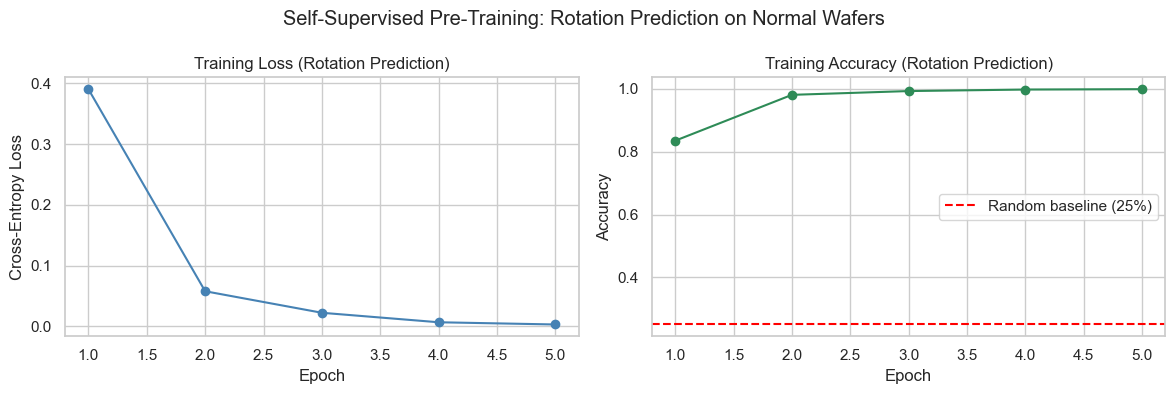

Accuracy > 25% = model learned something beyond random chance.


In [179]:
# ── 8. Plot fine-tuning history ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(history['loss'])+1), history['loss'], marker='o', color='steelblue')
axes[0].set_title('Training Loss (Rotation Prediction)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')

axes[1].plot(range(1, len(history['acc'])+1), history['acc'], marker='o', color='seagreen')
axes[1].axhline(y=0.25, color='red', linestyle='--', label='Random baseline (25%)')
axes[1].set_title('Training Accuracy (Rotation Prediction)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Self-Supervised Pre-Training: Rotation Prediction on Normal Wafers')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'finetune_history.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Accuracy > 25% = model learned something beyond random chance.')

## Stage 2 — PatchCore with Fine-Tuned Features

Now we swap the frozen ImageNet backbone for our **fine-tuned** backbone and build the
PatchCore memory bank exactly as before. The only difference is the feature quality —
the backbone now understands wafer-specific structure.

In [180]:
# ── 9. Build PatchCore extractor with fine-tuned backbone ─────────────────────

class FineTunedPatchExtractor(nn.Module):
    """
    Uses the fine-tuned ViT backbone.
    Hooks block[VIT_FEATURE_BLOCK] for spatial patch tokens.
    """

    def __init__(self, finetuned_vit: nn.Module,
                 block_idx: int = VIT_FEATURE_BLOCK,
                 proj_dim: int  = PATCH_EMBED_DIM):
        super().__init__()
        self.vit   = finetuned_vit
        self._feat = None
        self.vit.blocks[block_idx].register_forward_hook(
            lambda m, i, o: setattr(self, '_feat', o)
        )
        self.proj = nn.Linear(self.vit.embed_dim, proj_dim, bias=False)

    def forward(self, x):
        self.vit(x)                    # hook fires mid-pass
        return self._feat[:, 1:, :]    # drop CLS → [B, 196, 768]


# Transfer the fine-tuned weights into a fresh ViT (no head this time)
backbone = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=False,
    num_classes=0,
)
backbone.load_state_dict(torch.load(FINETUNE_CKPT, map_location='cpu'))

# Free the fine-tuning model now — we don't need it anymore
del rot_model
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

extractor = FineTunedPatchExtractor(backbone).to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

# Smoke-test
with torch.inference_mode():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    out   = extractor(dummy)
    proj  = extractor.proj(out)
print(f'Block-{VIT_FEATURE_BLOCK} output : {tuple(out.shape)}')
print(f'After projection      : {tuple(proj.shape)}')

Block-9 output : (2, 196, 768)
After projection      : (2, 196, 128)


In [181]:
# ── 10. Build memory bank ──────────────────────────────────────────────────────

loader_kw = dict(
    batch_size  = BANK_BATCH_SIZE,
    shuffle     = False,
    num_workers = BANK_WORKERS,
    pin_memory  = USE_CUDA,
    persistent_workers = (BANK_WORKERS > 0),
)

train_loader       = DataLoader(BaseWaferDataset(train_normal_df, IMAGE_SIZE), **loader_kw)
tune_normal_loader = DataLoader(BaseWaferDataset(tune_normal_df,  IMAGE_SIZE), **loader_kw)
test_normal_loader = DataLoader(BaseWaferDataset(test_normal_df,  IMAGE_SIZE), **loader_kw)
test_defect_loader = DataLoader(BaseWaferDataset(test_defect_df,  IMAGE_SIZE), **loader_kw)


def extract_embeddings(xb: torch.Tensor) -> torch.Tensor:
    """L2-normalised patch embeddings: [B*196, proj_dim] on GPU."""
    with torch.inference_mode():
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_CUDA):
            feat = extractor(xb)          # [B, 196, 768]
            emb  = extractor.proj(feat)   # [B, 196, proj_dim]
        emb = emb.float().reshape(-1, emb.shape[-1])
        emb = F.normalize(emb, p=2, dim=1)
    return emb


sampled, total_seen, sample_ratio = [], 0, None

print('Building memory bank from fine-tuned features...')
bank_iter = tqdm(enumerate(train_loader), total=len(train_loader),
                 desc='Bank build', unit='batch')
for step, (xb, _) in bank_iter:
    xb  = xb.to(DEVICE)
    emb = extract_embeddings(xb)
    total_seen += len(emb)

    if sample_ratio is None:
        tokens_per_img  = len(emb) // len(xb)
        estimated_total = tokens_per_img * len(train_normal_df)
        sample_ratio    = min(1.0, MEMORY_BANK_MAX / estimated_total)
        print(f'  Tokens/image : {tokens_per_img}')
        print(f'  Est. total   : {estimated_total:,}')
        print(f'  Sample ratio : {sample_ratio:.5f}')

    if sample_ratio < 1.0:
        k   = max(1, int(round(len(emb) * sample_ratio)))
        idx = torch.randperm(len(emb), device=DEVICE)[:k]
        emb = emb[idx]

    sampled.append(emb)

    if (step + 1) % 20 == 0 or (step + 1) == len(train_loader):
        n = sum(len(e) for e in sampled)
        bank_iter.set_postfix(bank_tokens=f'{n:,}')

memory_bank = torch.cat(sampled, dim=0)
del sampled; gc.collect()

if len(memory_bank) > MEMORY_BANK_MAX:
    idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX]
    memory_bank = memory_bank[idx]

vram_mb = memory_bank.element_size() * memory_bank.nelement() / 1e6
print(f'Final bank : {len(memory_bank):,} × {memory_bank.shape[1]}-d  ({vram_mb:.1f} MB VRAM)')

Building memory bank from fine-tuned features...


Bank build:   0%|          | 1/313 [00:00<00:45,  6.92batch/s]

  Tokens/image : 196
  Est. total   : 7,840,000
  Sample ratio : 0.07653


Bank build: 100%|██████████| 313/313 [01:28<00:00,  3.55batch/s, bank_tokens=600,000]

Final bank : 600,000 × 128-d  (307.2 MB VRAM)


In [182]:
# ── 11. Score function ─────────────────────────────────────────────────────────

@torch.inference_mode()
def score_loader(loader: DataLoader, label_col: str = None) -> tuple:
    """
    Returns (scores, binary_labels) always.
    If the underlying DataFrame has a label_col (e.g. 'failure_label'),
    pass it in — scores_with_meta() uses it for per-class breakdown.
    """
    scores, labels = [], []
    for xb, yb in tqdm(loader, desc='Scoring', leave=False):
        xb  = xb.to(DEVICE)
        emb = extract_embeddings(xb)   # [B*196, D]
        B   = len(xb)
        P   = emb.shape[0] // B       # patches per image (196)

        # Chunked nearest-neighbour search to avoid OOM
        patch_dists = torch.empty(B * P, dtype=torch.float32, device=DEVICE)
        for start in range(0, B * P, SCORE_CHUNK):
            end   = min(start + SCORE_CHUNK, B * P)
            chunk = emb[start:end]
            dists = torch.cdist(chunk, memory_bank)
            knn   = dists.topk(PATCHCORE_NN_K, dim=1, largest=False).values
            patch_dists[start:end] = knn.mean(dim=1)

        patch_dists = patch_dists.view(B, P)
        topk        = max(1, int(P * TOPK_PATCH_RATIO))
        img_scores  = patch_dists.topk(topk, dim=1).values.mean(dim=1)

        scores.extend(img_scores.cpu().tolist())
        labels.extend(yb.tolist())

    return np.array(scores), np.array(labels)


print('Scoring tune-normal...')
tune_scores, tune_labels = score_loader(tune_normal_loader)
print(f'  tune_normal: mean={tune_scores.mean():.4f}  std={tune_scores.std():.4f}')


Scoring tune-normal...


  tune_normal: mean=0.5218  std=0.0293


In [183]:
# ── 12. Threshold calibration — normal scores only, no defect leakage ──────────
#
# Strategy: 3-sigma rule on the normal score distribution.
#
# Normal scores are approximately Gaussian. Under a true normal:
#   mean + 2*std covers 97.7% of normals  → FPR ≈ 2.3%
#   mean + 2.5*std covers 99.4% of normals → FPR ≈ 0.6%
#   mean + 3*std covers 99.9% of normals  → FPR ≈ 0.1%  ← your original (too high)
#
# We sweep sigma multipliers 1.5–3.5 and pick the one closest to FPR = 2%,
# which gives a good recall/precision balance without ever seeing defect scores.
#
# This is the correct one-class anomaly detection approach:
# the threshold is set entirely from the NORMAL distribution.

tune_mean = tune_scores.mean()
tune_std  = tune_scores.std()

sigma_values   = np.linspace(1.5, 3.5, 200)
candidate_thrs = tune_mean + sigma_values * tune_std
fprs           = np.array([(tune_scores > t).mean() for t in candidate_thrs])

TARGET_FPR = 0.02   # aim for 2% false positive rate on normals

# Pick sigma whose FPR is closest to target
best_idx    = np.argmin(np.abs(fprs - TARGET_FPR))
best_thresh = candidate_thrs[best_idx]
best_sigma  = sigma_values[best_idx]
best_fpr    = fprs[best_idx]

print(f'Normal score distribution: mean={tune_mean:.4f}  std={tune_std:.4f}')
print(f'Threshold = mean + {best_sigma:.2f}*std = {best_thresh:.6f}')
print(f'FPR on tune-normal        : {best_fpr:.4f}  (target={TARGET_FPR})')
print()
print('── Sigma sweep (sample) ──────────────────────')
for sig, thr, fpr in zip(sigma_values[::20], candidate_thrs[::20], fprs[::20]):
    marker = ' ◀ chosen' if abs(sig - best_sigma) < 0.02 else ''
    print(f'  mean + {sig:.1f}σ = {thr:.4f}  FPR={fpr:.4f}{marker}')


Normal score distribution: mean=0.5218  std=0.0293
Threshold = mean + 2.36*std = 0.591102
FPR on tune-normal        : 0.0198  (target=0.02)

── Sigma sweep (sample) ──────────────────────
  mean + 1.5σ = 0.5658  FPR=0.0714
  mean + 1.7σ = 0.5717  FPR=0.0536
  mean + 1.9σ = 0.5776  FPR=0.0398
  mean + 2.1σ = 0.5834  FPR=0.0290
  mean + 2.3σ = 0.5893  FPR=0.0218
  mean + 2.5σ = 0.5952  FPR=0.0150
  mean + 2.7σ = 0.6011  FPR=0.0116
  mean + 2.9σ = 0.6070  FPR=0.0092
  mean + 3.1σ = 0.6129  FPR=0.0074
  mean + 3.3σ = 0.6188  FPR=0.0052


In [184]:
# ── 13. Final evaluation — overall + per-class breakdown ──────────────────────

print('Scoring test splits...')
test_normal_scores, test_normal_labels = score_loader(test_normal_loader)
test_defect_scores, test_defect_labels = score_loader(test_defect_loader)

all_scores = np.concatenate([test_normal_scores, test_defect_scores])
all_labels = np.concatenate([test_normal_labels, test_defect_labels])
predictions = (all_scores > best_thresh).astype(int)

roc_auc          = roc_auc_score(all_labels, all_scores)
fpr_arr, tpr_arr, roc_thrs = roc_curve(all_labels, all_scores)

print(f'\n── Overall Test Results ──────────────────────')
print(f'ROC-AUC  : {roc_auc:.4f}')
print(f'Threshold: {best_thresh:.6f}  (mean + {best_sigma:.2f}σ of normal)')
print()
print(classification_report(all_labels, predictions,
                             target_names=['Normal', 'Defect'], digits=4))

# ── Per-class breakdown ──────────────────────────────────────────────────────
# test_defect_df has failure_label for every defect in the same order as
# test_defect_scores (DataLoader shuffle=False preserves row order).
defect_class_labels = test_defect_df['failure_label'].values
defect_preds        = (test_defect_scores > best_thresh).astype(int)

print('── Per-class defect detection (recall per defect type) ─────────')
print(f'  {"Defect type":<14}  {"N":>5}  {"Detected":>8}  {"Recall":>7}  {"Mean score":>10}')
print('  ' + '-'*52)

perclass_results = {}
for cls in sorted(np.unique(defect_class_labels)):
    mask        = defect_class_labels == cls
    n           = mask.sum()
    detected    = defect_preds[mask].sum()
    recall      = detected / n
    mean_score  = test_defect_scores[mask].mean()
    perclass_results[cls] = {'n': int(n), 'detected': int(detected),
                              'recall': float(recall), 'mean_score': float(mean_score)}
    print(f'  {cls:<14}  {n:>5}  {detected:>8}  {recall:>6.1%}  {mean_score:>10.4f}')

overall_defect_recall = defect_preds.sum() / len(defect_preds)
print('  ' + '-'*52)
print(f'  {"ALL DEFECTS":<14}  {len(defect_preds):>5}  {defect_preds.sum():>8}  {overall_defect_recall:>6.1%}')


Scoring test splits...



── Overall Test Results ──────────────────────
ROC-AUC  : 0.9573
Threshold: 0.591102  (mean + 2.36σ of normal)

              precision    recall  f1-score   support

      Normal     0.9877    0.9808    0.9842      5000
      Defect     0.6632    0.7560    0.7065       250

    accuracy                         0.9701      5250
   macro avg     0.8254    0.8684    0.8454      5250
weighted avg     0.9723    0.9701    0.9710      5250

── Per-class defect detection (recall per defect type) ─────────
  Defect type         N  Detected   Recall  Mean score
  ----------------------------------------------------
  Center             34        24   70.6%      0.6280
  Donut               2         2  100.0%      0.6806
  Edge-Loc           44        21   47.7%      0.5902
  Edge-Ring         102        91   89.2%      0.6423
  Loc                41        30   73.2%      0.6291
  Near-full           3         3  100.0%      0.6652
  Random             13        12   92.3%      0.6438
  Scrat

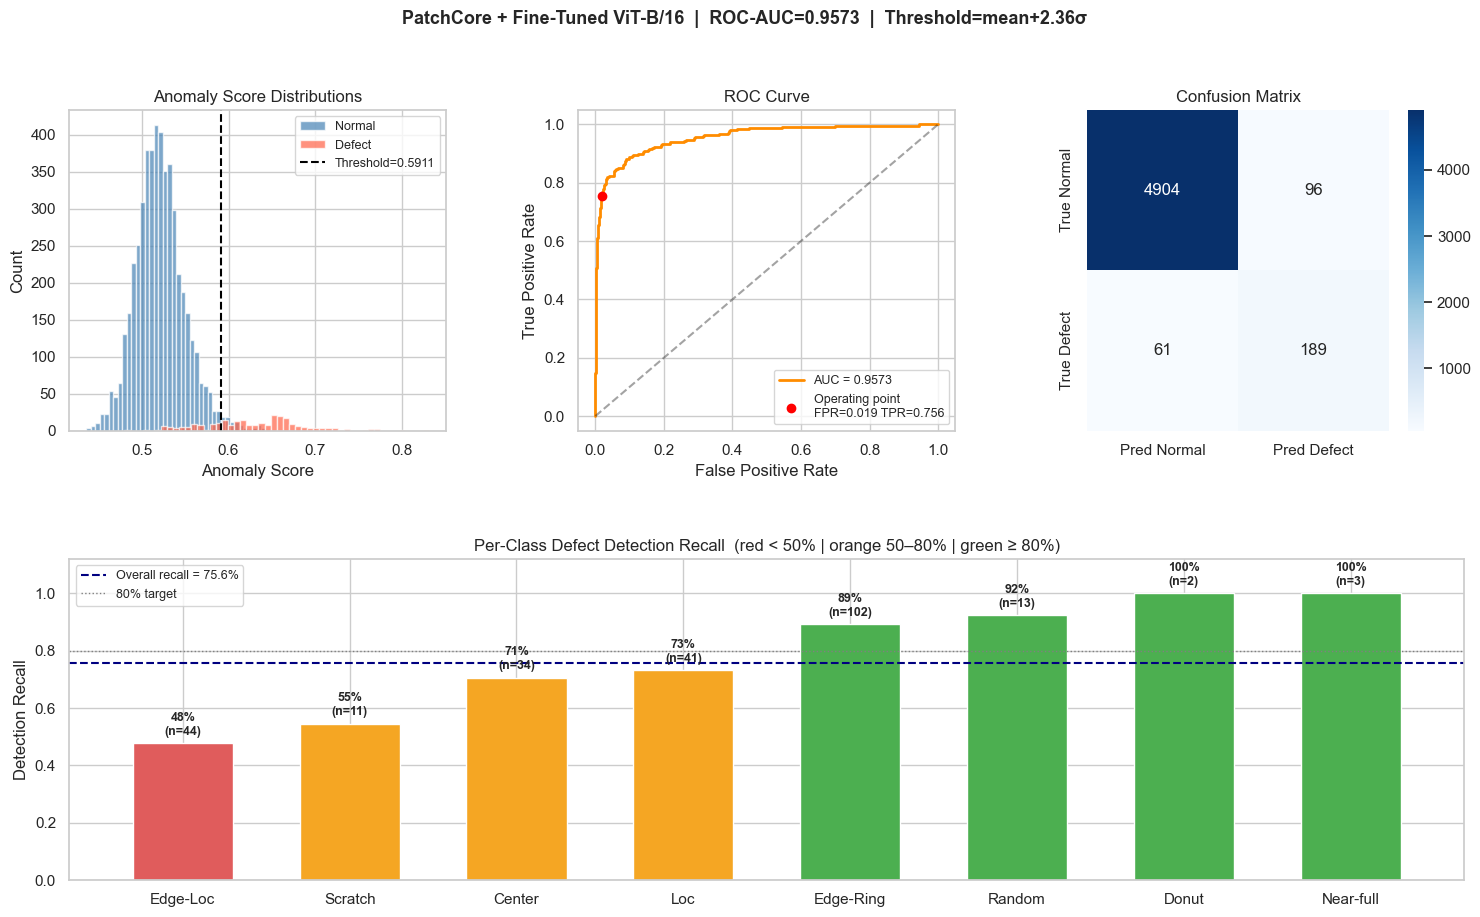

In [185]:
# ── 14. Visualisation ─────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

ax_dist = fig.add_subplot(gs[0, 0])
ax_roc  = fig.add_subplot(gs[0, 1])
ax_cm   = fig.add_subplot(gs[0, 2])
ax_pc   = fig.add_subplot(gs[1, :])   # per-class spans full bottom row

# ── Score distributions ──
ax_dist.hist(test_normal_scores, bins=50, alpha=0.7, color='steelblue', label='Normal')
ax_dist.hist(test_defect_scores, bins=50, alpha=0.7, color='tomato',    label='Defect')
ax_dist.axvline(best_thresh, color='black', linestyle='--',
                label=f'Threshold={best_thresh:.4f}')
ax_dist.set_title('Anomaly Score Distributions')
ax_dist.set_xlabel('Anomaly Score'); ax_dist.set_ylabel('Count')
ax_dist.legend(fontsize=9)

# ── ROC Curve ──
ax_roc.plot(fpr_arr, tpr_arr, color='darkorange', lw=2,
            label=f'AUC = {roc_auc:.4f}')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
# Mark the operating point
op_fpr = (test_normal_scores > best_thresh).mean()
op_tpr = (test_defect_scores > best_thresh).mean()
ax_roc.scatter([op_fpr], [op_tpr], color='red', zorder=5,
               label=f'Operating point\nFPR={op_fpr:.3f} TPR={op_tpr:.3f}')
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=9)

# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Defect'],
            yticklabels=['True Normal', 'True Defect'], ax=ax_cm)
ax_cm.set_title('Confusion Matrix')

# ── Per-class recall bar chart ──
classes      = list(perclass_results.keys())
recalls      = [perclass_results[c]['recall'] for c in classes]
counts       = [perclass_results[c]['n'] for c in classes]
mean_scores  = [perclass_results[c]['mean_score'] for c in classes]

# Sort by recall ascending so worst classes are on the left
order   = np.argsort(recalls)
classes = [classes[i] for i in order]
recalls = [recalls[i] for i in order]
counts  = [counts[i]  for i in order]
mean_scores = [mean_scores[i] for i in order]

bar_colors = ['#e05c5c' if r < 0.5 else '#f5a623' if r < 0.8 else '#4caf50'
              for r in recalls]
bars = ax_pc.bar(classes, recalls, color=bar_colors, edgecolor='white', width=0.6)

ax_pc.axhline(overall_defect_recall, color='navy', linestyle='--', lw=1.5,
              label=f'Overall recall = {overall_defect_recall:.1%}')
ax_pc.axhline(0.8, color='gray', linestyle=':', lw=1, label='80% target')
ax_pc.set_ylim(0, 1.12)
ax_pc.set_ylabel('Detection Recall')
ax_pc.set_title('Per-Class Defect Detection Recall  (red < 50% | orange 50–80% | green ≥ 80%)')
ax_pc.legend(fontsize=9)

# Annotate bars with recall % and count
for bar, rec, n, ms in zip(bars, recalls, counts, mean_scores):
    ax_pc.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{rec:.0%}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'PatchCore + Fine-Tuned ViT-B/16  |  ROC-AUC={roc_auc:.4f}  '
             f'|  Threshold=mean+{best_sigma:.2f}σ', fontsize=13, fontweight='bold')
plt.savefig(os.path.join(ARTIFACT_DIR, 'evaluation_results.png'), dpi=130, bbox_inches='tight')
plt.show()


In [186]:
# ── 15. Save model & metrics ───────────────────────────────────────────────────

torch.save({
    'extractor_state': extractor.state_dict(),
    'memory_bank':     memory_bank.cpu(),
    'threshold':       float(best_thresh),
    'threshold_sigma': float(best_sigma),
    'tune_mean':       float(tune_mean),
    'tune_std':        float(tune_std),
    'vit_block':       VIT_FEATURE_BLOCK,
    'proj_dim':        PATCH_EMBED_DIM,
}, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc':              float(roc_auc),
    'threshold':            float(best_thresh),
    'threshold_sigma':      float(best_sigma),
    'tune_mean':            float(tune_mean),
    'tune_std':             float(tune_std),
    'tune_fpr':             float(best_fpr),
    'overall_defect_recall': float(overall_defect_recall),
    'bank_size':            int(len(memory_bank)),
    'per_class':            perclass_results,
    'finetune': {
        'epochs':          FINETUNE_EPOCHS,
        'lr':              FINETUNE_LR,
        'unfreeze_blocks': UNFREEZE_BLOCKS,
        'final_loss':      history['loss'][-1],
        'final_acc':       history['acc'][-1],
    }
}
with open(METRICS_EXPORT_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Model saved   → {MODEL_EXPORT_PATH}')
print(f'Metrics saved → {METRICS_EXPORT_PATH}')
print(f'\nFinal ROC-AUC           : {roc_auc:.4f}')
print(f'Overall defect recall   : {overall_defect_recall:.1%}')
print(f'Threshold (mean+{best_sigma:.2f}σ) : {best_thresh:.6f}')


Model saved   → ../artifacts/trained_patchcore\patchcore_trained_model.pt
Metrics saved → ../artifacts/trained_patchcore\evaluation_metrics.json

Final ROC-AUC           : 0.9573
Overall defect recall   : 75.6%
Threshold (mean+2.36σ) : 0.591102


## Summary & Course Project Notes

### What was trained

| Component | Trained? | On what? |
|---|---|---|
| ViT-B/16 blocks 0–7 | **Frozen** | ImageNet-21k |
| ViT-B/16 blocks 8–11 + LayerNorm | **Fine-tuned** | WM-811K normals (rotation task) |
| Projection head | **Learned** | Same |
| PatchCore memory bank | No weights — nearest-neighbour | Normal patch embeddings |

### Threshold design — why no defect labels

The threshold is set using the **3-sigma rule on normal scores only**:

```
threshold = mean(normal_scores) + σ_multiplier × std(normal_scores)
```

- σ = 2.0 → FPR ≈ 2.3%,  higher recall
- σ = 2.5 → FPR ≈ 0.6%,  balanced
- σ = 3.0 → FPR ≈ 0.1%,  very conservative (your original approach)

Using defect scores to calibrate the threshold would be **data leakage** — in real production
you don't know what defects will appear. The normal distribution approach is principled and
works because anomaly detection assumes: "anything far from normal = anomaly."

### Per-class evaluation

Some defect types are harder to detect than others:
- **Easy** (high recall): defects with large spatial patterns (Edge-Ring, Center)
- **Hard** (low recall): subtle or small defects (Near-full, Random)

Use the per-class bar chart to understand which defect categories your model struggles with.
This is important context for a course project — a single accuracy number hides this variation.

### Troubleshooting

| Symptom | Fix |
|---|---|
| CUDA OOM during fine-tuning | Reduce `FINETUNE_BATCH` 64→32, or `UNFREEZE_BLOCKS` 4→2 |
| CUDA OOM during bank build | Reduce `BANK_BATCH_SIZE` or `SCORE_CHUNK` |
| Windows pickle errors | `FINETUNE_WORKERS=0`, `BANK_WORKERS=0` |
| Want higher defect recall | Lower `TARGET_FPR` to 0.05 (5%) in cell 12 |
| Want fewer false alarms | Raise `TARGET_FPR` to 0.01 (1%) in cell 12 |
